In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print("All libraries imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")

All libraries imported successfully!
pandas version: 3.0.2
numpy version: 2.4.4
scikit-learn version: 1.8.0


In [2]:
from sklearn.datasets import fetch_kddcup99

# Load dataset
print("Downloading KDD Cup 99 dataset... please wait")
data = fetch_kddcup99(subset='SA', as_frame=True, percent10=True)

# Convert to DataFrame
df = data.frame

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset loaded successfully!
Shape: (100655, 42)

First 5 rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,b'tcp',b'http',b'SF',181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,b'normal.'
1,0,b'tcp',b'http',b'SF',239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,b'normal.'
2,0,b'tcp',b'http',b'SF',235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
3,0,b'tcp',b'http',b'SF',219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,b'normal.'
4,0,b'tcp',b'http',b'SF',217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,b'normal.'


In [3]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nLabel Distribution:")
print(df['labels'].value_counts())

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100655 entries, 0 to 100654
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   duration                     100655 non-null  object
 1   protocol_type                100655 non-null  object
 2   service                      100655 non-null  object
 3   flag                         100655 non-null  object
 4   src_bytes                    100655 non-null  object
 5   dst_bytes                    100655 non-null  object
 6   land                         100655 non-null  object
 7   wrong_fragment               100655 non-null  object
 8   urgent                       100655 non-null  object
 9   hot                          100655 non-null  object
 10  num_failed_logins            100655 non-null  object
 11  logged_in                    100655 non-null  object
 12  num_compromised              100655 non-null  object
 13  root_shell 

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10976\3038429431.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


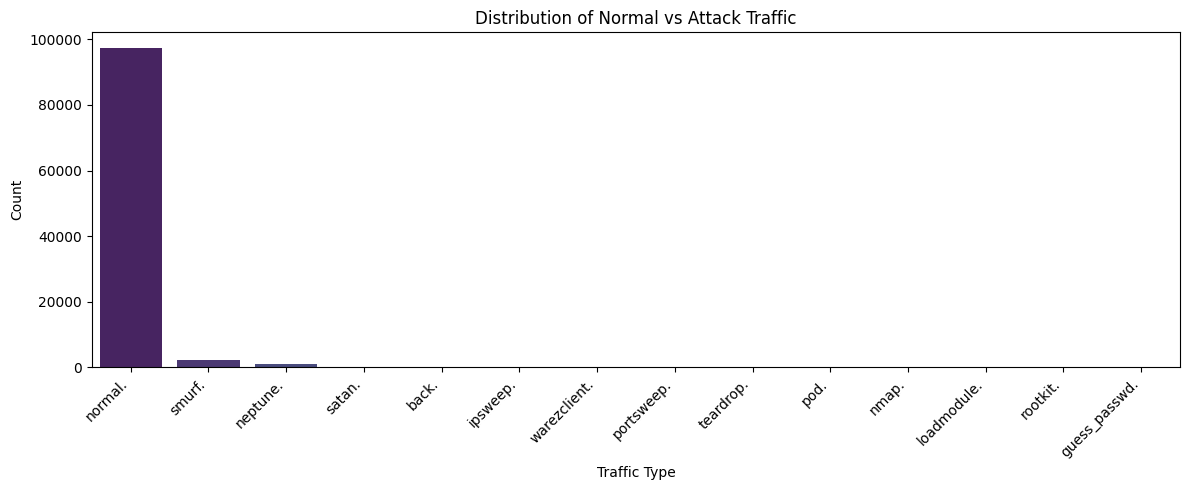


Total records: 100655
Number of unique labels: 14


In [4]:
# Cell 4 — Visualise label distribution
plt.figure(figsize=(12, 5))

# Count each label
label_counts = df['labels'].value_counts()

# Plot bar chart
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Normal vs Attack Traffic')
plt.xlabel('Traffic Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTotal records: {len(df)}")
print(f"Number of unique labels: {df['labels'].nunique()}")

In [5]:
# Cell 5 — Preprocessing

# Step 1 — Create binary label (normal=0, attack=1)
df['is_attack'] = df['labels'].apply(
    lambda x: 0 if x == b'normal.' else 1
)

print("Label encoding done!")
print(df['is_attack'].value_counts())
print(f"\nNormal traffic: {(df['is_attack']==0).sum()}")
print(f"Attack traffic: {(df['is_attack']==1).sum()}")

# Step 2 — Check categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

Label encoding done!
is_attack
0    97278
1     3377
Name: count, dtype: int64

Normal traffic: 97278
Attack traffic: 3377

Categorical columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'labels']


In [6]:
# Cell 6 — Encode features and prepare for ML

from sklearn.preprocessing import LabelEncoder

# Step 1 — Drop the original labels column (we have is_attack now)
df_clean = df.drop(columns=['labels'])

# Step 2 — Convert all byte string columns to regular strings
for col in df_clean.columns:
    if df_clean[col].dtype == object:
        df_clean[col] = df_clean[col].apply(
            lambda x: x.decode('utf-8') if isinstance(x, bytes) else x
        )

# Step 3 — Encode categorical text columns to numbers
le = LabelEncoder()
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

print("Encoding done!")
print(f"Shape: {df_clean.shape}")
print(f"\nData types after encoding:")
print(df_clean.dtypes.value_counts())
print(f"\nFirst 3 rows:")
df_clean.head(3)

Encoding done!
Shape: (100655, 42)

Data types after encoding:
int64      27
float64    15
Name: count, dtype: int64

First 3 rows:


C:\Users\Administrator\AppData\Local\Temp\ipykernel_10976\4218976722.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,is_attack
0,0,1,16,8,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,0
1,0,1,16,8,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,0
2,0,1,16,8,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,0


In [7]:
# Cell 7 — Split data and scale features

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1 — Separate features (X) and target (y)
X = df_clean.drop(columns=['is_attack'])
y = df_clean['is_attack']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Step 2 — Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

# Step 3 — Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nScaling done!")
print(f"Feature mean after scaling: {X_train_scaled.mean():.4f}")
print(f"Feature std after scaling: {X_train_scaled.std():.4f}")

Features shape: (100655, 41)
Target shape: (100655,)

Training set size: 80524
Test set size: 20131

Scaling done!
Feature mean after scaling: -0.0000
Feature std after scaling: 0.9753


In [8]:
# Cell 8 — Train Random Forest model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Step 1 — Create and train the model
print("Training Random Forest model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print("Training complete!")

# Step 2 — Make predictions
y_pred = rf_model.predict(X_test_scaled)

# Step 3 — Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, 
      target_names=['Normal', 'Attack']))

Training Random Forest model...
Training complete!

Accuracy: 1.0000 (100.00%)

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     19456
      Attack       1.00      1.00      1.00       675

    accuracy                           1.00     20131
   macro avg       1.00      1.00      1.00     20131
weighted avg       1.00      1.00      1.00     20131



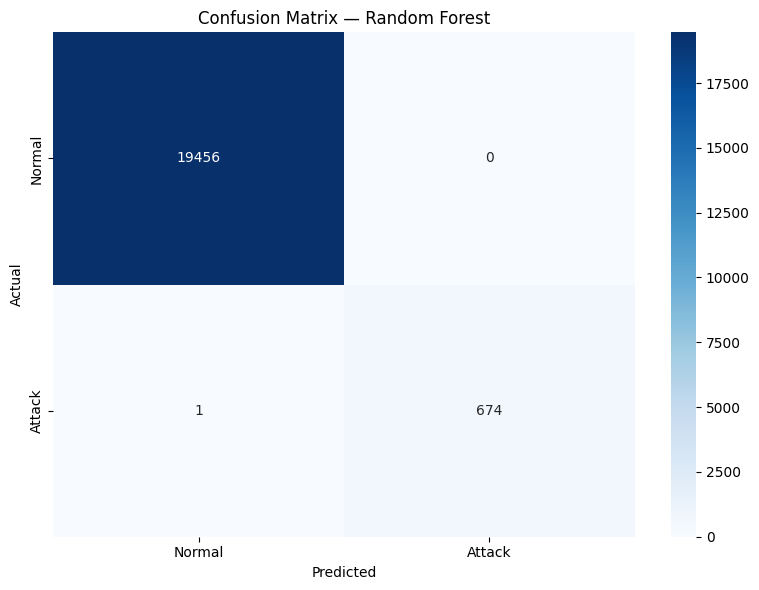


True Negatives (Normal correctly identified): 19456
False Positives (Normal flagged as Attack): 0
False Negatives (Attack missed): 1
True Positives (Attack correctly caught): 674


In [9]:
# Cell 9 — Confusion matrix visualisation

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Attack'],
            yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (Normal correctly identified): {cm[0][0]}")
print(f"False Positives (Normal flagged as Attack): {cm[0][1]}")
print(f"False Negatives (Attack missed): {cm[1][0]}")
print(f"True Positives (Attack correctly caught): {cm[1][1]}")

Calculating SHAP values... this may take a minute


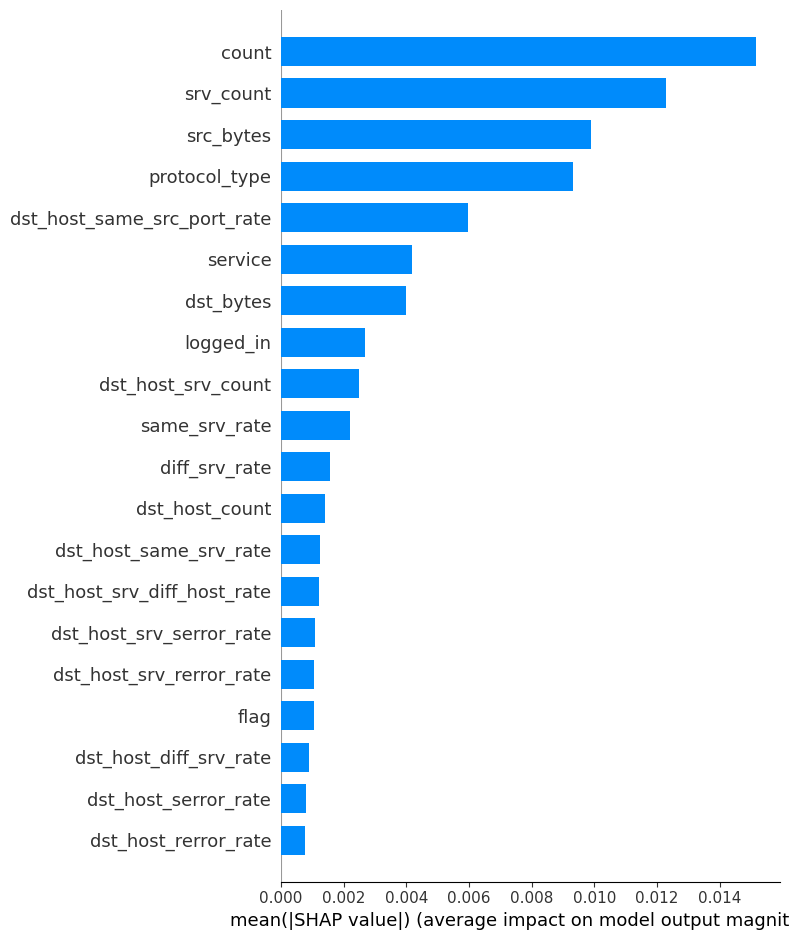


Top 10 most important features:
                    feature  importance
                      count    0.015165
                  srv_count    0.012280
                  src_bytes    0.009901
              protocol_type    0.009325
dst_host_same_src_port_rate    0.005971
                    service    0.004172
                  dst_bytes    0.004000
                  logged_in    0.002665
         dst_host_srv_count    0.002483
              same_srv_rate    0.002194


In [10]:
# Cell 10 — SHAP Explainability

import shap

print("Calculating SHAP values... this may take a minute")

# Create SHAP explainer
explainer = shap.TreeExplainer(rf_model)

# Use a small sample for speed (200 records)
X_sample = X_test_scaled[:200]
shap_values = explainer.shap_values(X_sample)

# Plot feature importance using SHAP
plt.figure()
shap.summary_plot(
    shap_values[:,:,1],
    X_sample,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=True
)

print("\nTop 10 most important features:")
feature_importance = pd.DataFrame({
    'feature': X.columns.tolist(),
    'importance': abs(shap_values[:,:,1]).mean(axis=0)
})
print(feature_importance.sort_values(
    'importance', ascending=False
).head(10).to_string(index=False))

In [11]:
# Cell 11 — Save the model and scaler

import pickle
import os

# Create models directory
os.makedirs('../src', exist_ok=True)

# Save the trained model
with open('../src/rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Save the scaler
with open('../src/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('../src/feature_names.pkl', 'wb') as f:
    pickle.dump(X.columns.tolist(), f)

print("Model saved successfully!")
print("Files saved:")
print("  - src/rf_model.pkl")
print("  - src/scaler.pkl")
print("  - src/feature_names.pkl")

Model saved successfully!
Files saved:
  - src/rf_model.pkl
  - src/scaler.pkl
  - src/feature_names.pkl
